# AmbitionBox Web Scraping & Analysis

## Analysis of Top 500 Companies

**Project Type:** Web Scraping & Data Analytics  
**Website:** AmbitionBox  
**Tools:** Python, Regex, Pandas, NumPy, Matplotlib, Seaborn  
**Environment:** Jupyter Notebook

## Project Introduction

AmbitionBox is a platform that provides information about companies, including employee ratings, reviews, salaries, industries, and workplace-related details.

This project uses web scraping and Python to collect and analyze publicly available data on the **Top 500 Companies** from AmbitionBox. The data will be cleaned, analyzed, and visualized to identify useful patterns and business insights.

## Problem Statement

Company information available on websites is often unstructured and difficult to compare directly.

This project aims to collect company data from AmbitionBox using web scraping, convert it into a structured dataset, and analyze the **Top 500 Companies** to identify meaningful trends in ratings, reviews, salaries, industries, and other available attributes.

## Project Objectives

- To collect company data from AmbitionBox using web scraping.
- To extract relevant information using Python and Regex.
- To clean and organize the scraped data.
- To perform Exploratory Data Analysis (EDA).
- To create meaningful visualizations and identify patterns.
- To derive business insights and provide recommendations.

## Tools & Technologies

- **Python** – Data collection, cleaning, and analysis
- **Jupyter Notebook** – Project development environment
- **Requests** – Fetching web pages
- **BeautifulSoup** – Extracting data from HTML
- **Regex (re)** – Extracting and processing text patterns
- **Pandas** – Data manipulation and analysis
- **NumPy** – Numerical operations
- **Matplotlib & Seaborn** – Data visualization

## Website Understanding

**Website:** AmbitionBox

AmbitionBox provides publicly available information about companies, including company ratings, employee reviews, salaries, industries, locations, and other workplace-related information.

The website is selected as the data source for analyzing the **Top 500 Companies** and identifying useful patterns and trends.

## Project Workflow

The project follows the complete data analytics workflow:

**Website Selection → Data Collection → Data Understanding → Data Cleaning → Exploratory Data Analysis → Data Visualization → Business Insights → Recommendations**

## Import Required Libraries

In [3]:
import requests
import re
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Check Library Versions
print("Pandas version:", pd.__version__)
print("NumPy version:", np.__version__)
print("Requests version:", requests.__version__)
print("BeautifulSoup: Imported successfully")
print("Regex: Imported successfully")
print("Matplotlib: Imported successfully")
print("Seaborn: Imported successfully")

Pandas version: 2.2.3
NumPy version: 2.2.4
Requests version: 2.32.3
BeautifulSoup: Imported successfully
Regex: Imported successfully
Matplotlib: Imported successfully
Seaborn: Imported successfully


## Data Collection Plan

The required company information will be collected from publicly available AmbitionBox web pages using Python web scraping techniques.

The scraped data will be stored in a structured format for further cleaning and analysis.

The main attributes will be selected based on the information actually available on the AmbitionBox pages.

In [3]:
url = "https://www.ambitionbox.com"
headers = {
    "User-Agent": "Mozilla/5.0"
}
response = requests.get(url, headers=headers)
print("Status Code:", response.status_code)

Status Code: 200


In [4]:
raw_data = []

print("Raw data container created successfully.")

Raw data container created successfully.


## Inspect AmbitionBox Company Page

Before collecting the complete dataset, the AmbitionBox company listing page will be inspected to understand its HTML structure and identify the elements containing company information.

In [5]:
# Open the Company Listing Page
company_url = "https://www.ambitionbox.com/list-of-companies"

headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
}

response = requests.get(company_url, headers=headers)

print("Status Code:", response.status_code)
print("Page Length:", len(response.text))

Status Code: 200
Page Length: 438678


In [6]:
#Creating BeautifulSoup Object
soup = BeautifulSoup(response.text, "html.parser")
print("BeautifulSoup object created successfully.")

BeautifulSoup object created successfully.


In [7]:
# Checking Title page
print("Page Title:")
print(soup.title.get_text(strip=True))

Page Title:
Top Companies in India | AmbitionBox


In [8]:
# Inspecting Main Headings
headings = soup.find_all(["h1", "h2", "h3"])
print("Number of headings found:", len(headings))
for heading in headings[:20]:
    print(heading.get_text(" ", strip=True))

Number of headings found: 25
Top Companies in INDIA
List of companies in India
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer


In [9]:
# Inspecting Company Links
company_links = []

for link in soup.find_all("a", href=True):
    text = link.get_text(" ", strip=True)
    href = link.get("href")

    if text and "company" in href.lower():
        company_links.append((text, href))

print("Company-related links found:", len(company_links))

for item in company_links[:20]:
    print(item)

Company-related links found: 4
('Create Company Profile', 'https://employer.ambitionbox.com/?utm_source=ambitionbox&utm_medium=desktop_nav&utm_campaign=create-new-company')
('Edit Company Profile', 'https://employer.ambitionbox.com/company-page?utm_source=ambitionbox&utm_medium=desktop_nav&utm_campaign=update-company-infomation')
('Employer Offerings', 'https://static.ambitionbox.com/alpha/company/photos/employer/AmbitionBox_Offering_For_Employers.pdf?campaign=ambitionbox_desktop_nav_ambitionBox_offering_for_employers')
('Employer Brochure', 'https://static.ambitionbox.com/alpha/company/photos/employer/AmbitionBox_Offering_For_Employers_Brochure.pdf?campaign=ambitionbox_desktop_nav_ambitionBox_offering_for_employers_brochure')


## Inspect Company Card Structure

The company listing page contains multiple company cards. Each card contains information such as company name, rating, reviews, industry, and location.

Before creating the complete scraper, we will inspect one company card to understand its HTML structure.

In [10]:
# Inspecting Company Card Structure
links = soup.find_all("a", href=True)
print("Total links found:", len(links))
for link in links[:10]:
    print("Text:", link.get_text(" ", strip=True))
    print("Href:", link.get("href"))
    print("-" * 50)

Total links found: 252
Text: AmbitionBox
Href: /
--------------------------------------------------
Text: Login
Href: javascript:void(0)
--------------------------------------------------
Text: Home
Href: /
--------------------------------------------------
Text: Companies
Href: /list-of-companies?campaign=desktop_nav
--------------------------------------------------
Text: Reviews
Href: /reviews?campaign=desktop_nav
--------------------------------------------------
Text: Salaries
Href: /salaries?campaign=desktop_nav
--------------------------------------------------
Text: Interview Questions
Href: /interviews?campaign=desktop_nav
--------------------------------------------------
Text: Jobs
Href: /jobs?campaign=desktop_nav
--------------------------------------------------
Text: Compare Companies
Href: /compare?campaign=desktop_nav
--------------------------------------------------
Text: Salary Calculator
Href: /salaries/take-home-salary-calculator?campaign=desktop_nav
--------------

## Find Company Names

In [11]:
# Finding Company Names
company_names = []

for link in soup.find_all("a", href=True):
    text = link.get_text(" ", strip=True)
    href = link.get("href", "")

    if text and "/company/" in href:
        company_names.append(text)
print("Company names found:", len(company_names))
for name in company_names[:20]:
    print(name)

Company names found: 2
Employer Offerings
Employer Brochure


## Remove Duplicate Company Names

In [12]:
# Removing Duplicate Company Names
unique_company_names = list(dict.fromkeys(company_names))
print("Unique companies found:", len(unique_company_names))
for name in unique_company_names[:20]:
    print(name)

Unique companies found: 2
Employer Offerings
Employer Brochure


In [13]:
# Inspecting First Company Element
first_company = soup.find("a", href=re.compile("/company/"))
print(first_company.prettify()[:3000])

<a class="nav-menu-item" data-testid="nav-menu-item" data-v-067a90c0="" data-v-410c6b07="" href="https://static.ambitionbox.com/alpha/company/photos/employer/AmbitionBox_Offering_For_Employers.pdf?campaign=ambitionbox_desktop_nav_ambitionBox_offering_for_employers" rel="noopener noreferrer" target="_blank">
 <div class="nav-menu-item__inner nav-menu-item__inner--hoverable" data-v-410c6b07="">
  <img alt="" aria-hidden="true" class="nav-menu-item__icon-left" data-v-410c6b07="" height="20" src="https://static.ambitionbox.com/static/leftNavBar/employer_offerings.svg" width="20"/>
  <span class="nav-menu-item__label" data-v-410c6b07="">
   Employer Offerings
  </span>
  <!-- -->
  <!-- -->
 </div>
</a>



In [14]:
# Finding Actual Company Links
actual_company_links = []

for link in soup.find_all("a", href=True):
    text = link.get_text(" ", strip=True)
    href = link.get("href", "")

    if href.startswith("/company/") and text:
        actual_company_links.append((text, href))

print("Actual company links found:", len(actual_company_links))

for item in actual_company_links[:20]:
    print(item)

Actual company links found: 0


In [15]:
# Checking Company Link Format

for item in actual_company_links[:10]:
    print("Company Name:", item[0])
    print("Company URL:", item[1])
    print("-" * 60)

In [16]:
# Checking Page Content

page_text = soup.get_text(" ", strip=True)

print(page_text[:5000])

Top Companies in India | AmbitionBox AmbitionBox Search About Company Reviews Salaries Interview Questions About Company Benefits Jobs Office Photos Community + Contribute 0 Login Home Companies Reviews Salaries Interview Questions Jobs Tools Compare Companies Salary Calculator Are you paid fairly? Evaluate Offer Letter Gratuity Calculator HRA Calculator Salary Hike Calculator Awards ABECA 2027 Rate Now ABECA 2026 ABECA 2025 Communities FOR EMPLOYERS Create Company Profile Edit Company Profile Respond to reviews Invite employees to review Employer Offerings Employer Brochure More About Us Our Team Email Us Privacy Grievances Terms of Use Community Guidelines Credits Summons/Notices Blog FAQ All rights reserved © 2026 Info Edge (India) Ltd. Top Companies in INDIA Curated by AmbitionBox By Industries IT Services & Consulting Engineering & Construction Auto Components View all industries By Locations Bengaluru Mumbai Pune View all locations By Designation Sales Executive Area Sales Manage

In [17]:
# Finding TCS on the Page

tcs_text = soup.find(string=re.compile(r"^TCS$", re.IGNORECASE))

print("TCS found:", tcs_text is not None)

TCS found: False


In [18]:
# Finding TCS Text

tcs_matches = soup.find_all(string=re.compile("TCS", re.IGNORECASE))

print("TCS matches found:", len(tcs_matches))

for match in tcs_matches[:10]:
    print(repr(match))

TCS matches found: 2
'\n\t\t\t\t\t\t\t\t\tTCS\n\t\t\t\t\t\t\t\t'
'window.__NUXT__=(function(a,b,c,d,e,f,g,h,i,j,k,l,m,n,o,p,q,r,s,t,u,v,w,x,y,z,A,B,C,D,E,F,G,H,I,J,K,L,M,N,O,P,Q,R,S,T,U,V,W,X,Y,Z,_,$,aa,ab,ac,ad,ae,af,ag,ah,ai,aj,ak,al,am,an,ao,ap,aq,ar,as,at,au,av,aw,ax,ay,az,aA,aB,aC,aD,aE,aF,aG,aH,aI,aJ,aK,aL,aM,aN,aO,aP,aQ,aR,aS,aT,aU,aV,aW,aX,aY,aZ,a_,a$,ba,bb,bc,bd,be,bf,bg,bh,bi,bj,bk,bl,bm,bn,bo,bp,bq,br,bs,bt,bu,bv,bw,bx,by,bz,bA,bB,bC,bD,bE,bF,bG,bH,bI,bJ,bK,bL,bM,bN,bO,bP,bQ,bR,bS,bT,bU,bV,bW,bX,bY,bZ,b_,b$,ca,cb,cc,cd,ce,cf,cg,ch,ci,cj,ck,cl,cm,cn,co,cp,cq,cr,cs,ct,cu,cv,cw,cx,cy,cz,cA,cB,cC,cD,cE,cF,cG,cH,cI,cJ,cK,cL,cM,cN,cO,cP,cQ,cR,cS,cT,cU,cV,cW,cX,cY,cZ,c_,c$,da,db,dc,dd,de,df,dg,dh,di,dj,dk,dl,dm,dn,do0,dp,dq,dr,ds,dt,du,dv,dw,dx,dy,dz,dA,dB,dC,dD,dE,dF,dG,dH,dI,dJ,dK,dL,dM,dN,dO,dP,dQ,dR,dS,dT,dU,dV,dW,dX,dY,dZ,d_,d$,ea,eb,ec,ed,ee,ef,eg,eh,ei,ej,ek,el,em,en,eo,ep,eq,er,es,et,eu,ev,ew,ex,ey,ez,eA,eB,eC,eD,eE,eF,eG,eH,eI,eJ,eK,eL,eM,eN,eO,eP,eQ,eR,eS,eT,eU,eV,eW,eX,e

In [19]:
# Inspecting TCS Match

if tcs_matches:
    print(tcs_matches[0].parent.prettify()[:3000])
else:
    print("No TCS match found.")

<h2 class="companyCardWrapper__companyName" title="TCS">
 TCS
</h2>



## Inspect TCS Parent Structure

In [20]:
# Inspecting TCS Parent Structure

tcs_element = tcs_matches[0].parent

print("TCS Element:")
print(tcs_element)

print("\nParent 1:")
print(tcs_element.parent.name, tcs_element.parent.get("class"))

print("\nParent 2:")
print(tcs_element.parent.parent.name, tcs_element.parent.parent.get("class"))

print("\nParent 3:")
print(tcs_element.parent.parent.parent.name, tcs_element.parent.parent.parent.get("class"))

print("\nParent 4:")
print(tcs_element.parent.parent.parent.parent.name, tcs_element.parent.parent.parent.parent.get("class"))

TCS Element:
<h2 class="companyCardWrapper__companyName" title="TCS">
									TCS
								</h2>

Parent 1:
a ['companyCardWrapper__companyName']

Parent 2:
div ['companyCardWrapper__companyPrimaryDetailsTopSection']

Parent 3:
div ['companyCardWrapper__header']

Parent 4:
div ['companyCardWrapper__metaInformation']


## Find All Company Name Elements

In [21]:
# Finding Company Name Elements

company_elements = soup.find_all(
    "h2",
    class_=re.compile("companyCardWrapper__companyName")
)

print("Company name elements found:", len(company_elements))

for company in company_elements[:20]:
    print(company.get_text(" ", strip=True))

Company name elements found: 20
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
IBM


## Check the Number of Companies

In [22]:
# Checking Number of Companies

print("Total company cards found:", len(company_elements))

Total company cards found: 20


## Extract TCS Company Card

In [23]:
# Extracting TCS Company Card

tcs_element = soup.find(
    "h2",
    class_=re.compile("companyCardWrapper__companyName")
)

card = tcs_element

while card.parent:
    card = card.parent
    
    if card.get("class") and any(
        "companyCardWrapper" in cls for cls in card.get("class")
    ):
        break

print(card.get_text(" | ", strip=True))

TCS


## Inspect TCS Company Card HTM

In [24]:
# Inspecting TCS Company Card HTML

print(card.prettify()[:8000])

<a class="companyCardWrapper__companyName">
 <h2 class="companyCardWrapper__companyName" title="TCS">
  TCS
 </h2>
</a>



In [25]:
# Finding Text Elements Inside Company Card

texts = card.find_all(["h2", "div", "span", "a"])

for element in texts:
    text = element.get_text(" ", strip=True)

    if text:
        print(element.name, "|", text[:200])

h2 | TCS


## Create a Temporary Company Record

In [26]:
# Creating Temporary Company Record

tcs_record = {
    "Company Name": tcs_element.get_text(" ", strip=True),
    "Card Text": card.get_text(" | ", strip=True)
}

print(tcs_record)

{'Company Name': 'TCS', 'Card Text': 'TCS'}


## Identify Company Card

In [27]:
# Identifying Company Cards

company_elements = soup.find_all(
    "h2",
    class_=re.compile("companyCardWrapper__companyName")
)

print("Company name elements found:", len(company_elements))

for company in company_elements[:20]:
    print(company.get_text(" ", strip=True))

Company name elements found: 20
TCS
Accenture
Wipro
Cognizant
Capgemini
HDFC Bank
Infosys
HCLTech
ICICI Bank
Tech Mahindra
Genpact
TP
Axis Bank
Jio
Concentrix Corporation
Amazon
Reliance Retail
iEnergizer
LTM Limited
IBM


## Find the Complete Company Card

In [28]:
# Finding Complete Company Card
first_company = company_elements[0]
card = first_company
for _ in range(10):
    if card.parent is None:
        break

    card = card.parent

    classes = card.get("class", [])

    if any("companyCardWrapper" in str(cls) for cls in classes):
        break
print("Card classes:", card.get("class"))

Card classes: ['companyCardWrapper__companyName']


In [29]:
# Extracting First Company Raw Data

first_company_raw = card.get_text(" | ", strip=True)

print(first_company_raw)

TCS


## Inspect Multiple Company Cards

In [30]:
# Inspecting Multiple Company Cards
for company in company_elements[:5]:
    card = company

    for _ in range(10):
        if card.parent is None:
            break

        card = card.parent

        classes = card.get("class", [])

        if any("companyCardWrapper" in str(cls) for cls in classes):
            break

print("\n", "=" * 100)
print(card.get_text(" | ", strip=True))


Capgemini


In [31]:
# Creating Raw Company Records

raw_company_data = []

for company in company_elements:
    card = company

    for _ in range(10):
        if card.parent is None:
            break

        card = card.parent

        classes = card.get("class", [])

        if any("companyCardWrapper" in str(cls) for cls in classes):
            break

    record = {
        "Company Name": company.get_text(" ", strip=True),
        "Raw Card Text": card.get_text(" | ", strip=True)
    }

    raw_company_data.append(record)

print("Raw company records created:", len(raw_company_data))

Raw company records created: 20


In [32]:
# Previewing Raw Dataset

raw_df = pd.DataFrame(raw_company_data)

print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

raw_df.head(10)

Rows: 20
Columns: 2


,Company Name,Raw Card Text
0,TCS,TCS
1,Accenture,Accenture
2,Wipro,Wipro
3,Cognizant,Cognizant
4,Capgemini,Capgemini
5,HDFC Bank,HDFC Bank
6,Infosys,Infosys
7,HCLTech,HCLTech
8,ICICI Bank,ICICI Bank
9,Tech Mahindra,Tech Mahindra


## Extract Complete Company Card

In [34]:
# Testing Complete Company Card

test_card = get_complete_card(company_elements[0])

print("Card found:", test_card is not None)

if test_card:
    print(test_card.get_text(" | ", strip=True))

Card found: True
TCS | Follow | 3.2 | (1.2L) | IT Services & Consulting | Bengaluru +481 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 1.2L | Reviews | 10.4L | Salaries | 11.4k | Interviews | 4.6k | Jobs | 11.1k | Benefits | 100 | Photos


In [35]:
# Creating Corrected Raw Company Dataset

raw_company_data = []

for company in company_elements:
    card = get_complete_card(company)

    if card:
        record = {
            "Company Name": company.get_text(" ", strip=True),
            "Raw Card Text": card.get_text(" | ", strip=True)
        }

        raw_company_data.append(record)

print("Raw company records created:", len(raw_company_data))

Raw company records created: 20


In [36]:
# Previewing Corrected Raw Dataset

raw_df = pd.DataFrame(raw_company_data)

print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

raw_df.head(10)

Rows: 20
Columns: 2


,Company Name,Raw Card Text
0,TCS,TCS | Follow | 3.2 | (1.2L) | IT Services & Co...
1,Accenture,Accenture | Follow | 3.7 | (77.6k) | IT Servic...
2,Wipro,Wipro | Follow | 3.6 | (68.3k) | IT Services &...
3,Cognizant,Cognizant | Follow | 3.7 | (64.5k) | IT Servic...
4,Capgemini,Capgemini | Follow | 3.6 | (56.7k) | IT Servic...
5,HDFC Bank,HDFC Bank | Follow | 3.8 | (55.7k) | Banking |...
6,Infosys,Infosys | Follow | 3.5 | (51.4k) | IT Services...
7,HCLTech,HCLTech | Follow | 3.4 | (48.5k) | IT Services...
8,ICICI Bank,ICICI Bank | Follow | 4.0 | (47.7k) | Banking ...
9,Tech Mahindra,Tech Mahindra | Follow | 3.3 | (45.6k) | IT Se...


## Test Pagination

In [37]:
# Testing Page 2

page_2_url = "https://www.ambitionbox.com/list-of-companies?page=2"

response_page_2 = requests.get(page_2_url, headers=headers)

print("Status Code:", response_page_2.status_code)
print("Page Length:", len(response_page_2.text))

soup_page_2 = BeautifulSoup(response_page_2.text, "html.parser")

page_2_companies = soup_page_2.find_all(
    "h2",
    class_=re.compile("companyCardWrapper__companyName")
)

print("Companies found on Page 2:", len(page_2_companies))

for company in page_2_companies[:5]:
    print(company.get_text(" ", strip=True))

Status Code: 200
Page Length: 443069
Companies found on Page 2: 20
HDB Financial Services
Larsen & Toubro Limited
Deloitte
Kotak Mahindra Bank
Reliance Industries


## Collect Top 500 Companies

In [38]:
# Collecting Top 500 Companies

all_company_data = []

for page in range(1, 26):

    page_url = f"https://www.ambitionbox.com/list-of-companies?page={page}"

    response = requests.get(page_url, headers=headers)

    soup_page = BeautifulSoup(response.text, "html.parser")

    companies = soup_page.find_all(
        "h2",
        class_=re.compile("companyCardWrapper__companyName")
    )

    print(f"Page {page}: {len(companies)} companies")

    for company in companies:

        card = get_complete_card(company)

        if card:
            record = {
                "Company Name": company.get_text(" ", strip=True),
                "Raw Card Text": card.get_text(" | ", strip=True)
            }

            all_company_data.append(record)

print("Total records collected:", len(all_company_data))

Page 1: 20 companies
Page 2: 20 companies
Page 3: 20 companies
Page 4: 20 companies
Page 5: 20 companies
Page 6: 20 companies
Page 7: 20 companies
Page 8: 20 companies
Page 9: 20 companies
Page 10: 20 companies
Page 11: 20 companies
Page 12: 20 companies
Page 13: 20 companies
Page 14: 20 companies
Page 15: 20 companies
Page 16: 20 companies
Page 17: 20 companies
Page 18: 20 companies
Page 19: 20 companies
Page 20: 20 companies
Page 21: 20 companies
Page 22: 20 companies
Page 23: 20 companies
Page 24: 20 companies
Page 25: 20 companies
Total records collected: 500


## Why This Step Is Important

Instead of collecting company data manually, pagination allows us to automatically scrape multiple pages from AmbitionBox.

Each page contains a set of company records. By iterating through pages 1 to 25, we can collect the required Top 500 companies efficiently and maintain a consistent scraping process.

The raw card text is preserved at this stage because it contains the original information extracted from the website. We will later use Regex and data-cleaning techniques to convert this unstructured text into separate columns.

In [39]:
# Validating Collected Company Data

collected_df = pd.DataFrame(all_company_data)

print("Total records:", len(collected_df))
print("Unique companies:", collected_df["Company Name"].nunique())
print("Duplicate records:", collected_df["Company Name"].duplicated().sum())

Total records: 500
Unique companies: 495
Duplicate records: 5


In [40]:
# Creating Raw DataFrame

raw_df = pd.DataFrame(all_company_data)

print("Raw dataset shape:", raw_df.shape)

raw_df.head()

Raw dataset shape: (500, 2)


,Company Name,Raw Card Text
0,TCS,TCS | Follow | 3.2 | (1.2L) | IT Services & Co...
1,Accenture,Accenture | Follow | 3.7 | (77.6k) | IT Servic...
2,Wipro,Wipro | Follow | 3.6 | (68.3k) | IT Services &...
3,Cognizant,Cognizant | Follow | 3.7 | (64.4k) | IT Servic...
4,Capgemini,Capgemini | Follow | 3.6 | (56.6k) | IT Servic...


In [41]:
# Saving Raw Dataset

raw_file_path = "../02_Raw_Data/AmbitionBox_Top_500_Raw_Data.csv"

raw_df.to_csv(raw_file_path, index=False)

print("Raw dataset saved successfully.")

Raw dataset saved successfully.


## Raw Dataset

The scraped company information is now stored in a structured DataFrame and saved as a CSV file.

The raw dataset contains the original company names and the complete text extracted from each company card. This raw version is preserved before applying any cleaning or transformation.

Keeping a raw dataset is important because it provides a reference copy of the original scraped data and allows us to reproduce or verify the cleaning process later.

In [42]:
# Inspecting Raw Dataset

print("Rows:", raw_df.shape[0])
print("Columns:", raw_df.shape[1])

raw_df.info()

Rows: 500
Columns: 2
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Company Name   500 non-null    object
 1   Raw Card Text  500 non-null    object
dtypes: object(2)
memory usage: 7.9+ KB


In [43]:
# Checking Missing Values

missing_values = raw_df.isnull().sum()

print(missing_values)

Company Name     0
Raw Card Text    0
dtype: int64


## Initial Data Understanding

Before cleaning the dataset, we inspect its structure, number of records, columns, and missing values.

This step helps us understand the quality and structure of the scraped data before applying Regex and other data-cleaning techniques.

## Regex-Based Data Extraction

The raw company card contains multiple pieces of information in a single text field.

Regular Expressions (Regex) will be used to identify specific patterns such as company ratings, review counts, and other structured information from the raw text.

This converts unstructured scraped text into separate analytical columns.

In [44]:
# Extracting Company Rating Using Regex
def extract_rating(text):
    match = re.search(r"\b([0-5](?:\.[0-9])?)\b", text)
    
    if match:
        return float(match.group(1))
    
    return np.nan


raw_df["Company Rating"] = raw_df["Raw Card Text"].apply(extract_rating)

raw_df[["Company Name", "Company Rating"]].head(10)

,Company Name,Company Rating
0,TCS,3.2
1,Accenture,3.7
2,Wipro,3.6
3,Cognizant,3.7
4,Capgemini,3.6
5,HDFC Bank,3.8
6,Infosys,3.5
7,HCLTech,3.4
8,ICICI Bank,4.0
9,Tech Mahindra,3.3


In [45]:
# Checking Extracted Ratings

print("Ratings extracted:", raw_df["Company Rating"].notna().sum())
print("Missing ratings:", raw_df["Company Rating"].isna().sum())

print("\nRating range:")
print(raw_df["Company Rating"].min(), "to", raw_df["Company Rating"].max())

Ratings extracted: 499
Missing ratings: 1

Rating range:
2.7 to 4.9


## Understanding Rating Extraction

The Regex pattern searches the raw company-card text for a rating value between 0 and 5, including decimal ratings such as 3.2 or 4.5.

The extracted rating is stored in a separate numeric column so that it can be used later for EDA, comparisons, and visualizations.

In [46]:
# Extracting Number of Reviews Using Regex

def extract_reviews(text):
    match = re.search(r"\(([\d,.]+[KLM]?)\)", text)
    
    if match:
        return match.group(1)
    
    return np.nan


raw_df["Reviews"] = raw_df["Raw Card Text"].apply(extract_reviews)

raw_df[["Company Name", "Company Rating", "Reviews"]].head(10)

,Company Name,Company Rating,Reviews
0,TCS,3.2,1.2L
1,Accenture,3.7,NaN
2,Wipro,3.6,NaN
3,Cognizant,3.7,NaN
4,Capgemini,3.6,NaN
5,HDFC Bank,3.8,NaN
6,Infosys,3.5,NaN
7,HCLTech,3.4,NaN
8,ICICI Bank,4.0,NaN
9,Tech Mahindra,3.3,NaN


In [48]:
# Converting Review Counts to Numeric Values

def convert_reviews(value):
    if pd.isna(value):
        return np.nan
    
    value = str(value).replace(",", "")
    
    multiplier = 1
    
    if value.endswith("K"):
        multiplier = 1000
        value = value[:-1]
    elif value.endswith("L"):
        multiplier = 100000
        value = value[:-1]
    elif value.endswith("M"):
        multiplier = 1000000
        value = value[:-1]
    
    return float(value) * multiplier


raw_df["Reviews"] = raw_df["Reviews"].apply(convert_reviews)

raw_df[["Company Name", "Reviews"]].head(10)

,Company Name,Reviews
0,TCS,1040000.0
1,Accenture,730000.0
2,Wipro,490000.0
3,Cognizant,610000.0
4,Capgemini,500000.0
5,HDFC Bank,150000.0
6,Infosys,530000.0
7,HCLTech,400000.0
8,ICICI Bank,160000.0
9,Tech Mahindra,280000.0


In [49]:
# Checking Review Data

print("Reviews extracted:", raw_df["Reviews"].notna().sum())
print("Missing reviews:", raw_df["Reviews"].isna().sum())

raw_df["Reviews"].describe()

Reviews extracted: 499
Missing reviews: 1


count    4.990000e+02
mean     1.328553e+04
std      8.130616e+04
min      1.000000e+00
25%      8.800000e+00
50%      1.320000e+01
75%      2.415000e+01
max      1.040000e+06
Name: Reviews, dtype: float64

## Understanding Review Extraction

The number of reviews is extracted from the raw company-card text using Regex.

Values such as `1.2L` or `25K` are converted into numeric values so they can be used for statistical analysis, ranking, and visualization.

Keeping this information as a numeric field will make it easier to compare companies based on employee review volume.

## Extract Industry

Industry information helps us understand which sectors are represented among the Top 500 companies.

We will extract the industry text from the raw company-card information and store it as a separate column for further analysis.

In [50]:
# Extracting Industry

def extract_industry(text):
    parts = [part.strip() for part in text.split("|") if part.strip()]
    
    for part in parts:
        if "Services & Consulting" in part:
            return part
    
    return np.nan


raw_df["Industry"] = raw_df["Raw Card Text"].apply(extract_industry)

raw_df[["Company Name", "Industry"]].head(10)

,Company Name,Industry
0,TCS,IT Services & Consulting
1,Accenture,IT Services & Consulting
2,Wipro,IT Services & Consulting
3,Cognizant,IT Services & Consulting
4,Capgemini,IT Services & Consulting
5,HDFC Bank,NaN
6,Infosys,IT Services & Consulting
7,HCLTech,IT Services & Consulting
8,ICICI Bank,NaN
9,Tech Mahindra,IT Services & Consulting


In [51]:
# Correcting Industry Extraction

def extract_industry(text):
    parts = [part.strip() for part in text.split("|")]

    if len(parts) > 4:
        return parts[4]

    return np.nan


raw_df["Industry"] = raw_df["Raw Card Text"].apply(extract_industry)

raw_df[["Company Name", "Industry"]].head(10)

,Company Name,Industry
0,TCS,IT Services & Consulting
1,Accenture,IT Services & Consulting
2,Wipro,IT Services & Consulting
3,Cognizant,IT Services & Consulting
4,Capgemini,IT Services & Consulting
5,HDFC Bank,Banking
6,Infosys,IT Services & Consulting
7,HCLTech,IT Services & Consulting
8,ICICI Bank,Banking
9,Tech Mahindra,IT Services & Consulting


In [52]:
# Checking Industry Data

print("Industry values extracted:", raw_df["Industry"].notna().sum())
print("Missing industry values:", raw_df["Industry"].isna().sum())

print("\nTop Industries:")
print(raw_df["Industry"].value_counts().head(10))

Industry values extracted: 500
Missing industry values: 0

Top Industries:
Industry
IT Services & Consulting             73
Pharma                               30
Banking                              26
BPO                                  25
Insurance                            25
Financial Services                   23
NBFC                                 23
Internet                             21
Automobile                           18
Consumer Electronics & Appliances    17
Name: count, dtype: int64


## Understanding Industry Extraction

Industry is stored as a categorical field because companies can be grouped according to their industry or business sector.

This field will later help us identify the most common industries among the Top 500 companies and compare company ratings and review activity across sectors.

## Extract Location

Location provides information about where the company is headquartered or where its major offices are located.

This field will allow us to understand the geographical distribution of the companies in the dataset.

In [53]:
# Extracting Location

def extract_location(text):
    parts = [part.strip() for part in text.split("|") if part.strip()]
    
    for part in parts:
        if "other locations" in part.lower():
            return part
    
    return np.nan


raw_df["Location"] = raw_df["Raw Card Text"].apply(extract_location)

raw_df[["Company Name", "Location"]].head(10)

,Company Name,Location
0,TCS,Bengaluru +481 other locations
1,Accenture,Bengaluru +283 other locations
2,Wipro,Hyderabad +394 other locations
3,Cognizant,Hyderabad +255 other locations
4,Capgemini,Bengaluru +209 other locations
5,HDFC Bank,Mumbai +1916 other locations
6,Infosys,Bengaluru +263 other locations
7,HCLTech,Bengaluru +252 other locations
8,ICICI Bank,Mumbai +1480 other locations
9,Tech Mahindra,Hyderabad +340 other locations


In [54]:
# Correcting Location Extraction

def extract_location(text):
    parts = [part.strip() for part in text.split("|")]

    if len(parts) > 5:
        return parts[5]

    return np.nan


raw_df["Location"] = raw_df["Raw Card Text"].apply(extract_location)

raw_df[["Company Name", "Location"]].head(10)

,Company Name,Location
0,TCS,Bengaluru +481 other locations
1,Accenture,Bengaluru +283 other locations
2,Wipro,Hyderabad +394 other locations
3,Cognizant,Hyderabad +255 other locations
4,Capgemini,Bengaluru +209 other locations
5,HDFC Bank,Mumbai +1916 other locations
6,Infosys,Bengaluru +263 other locations
7,HCLTech,Bengaluru +252 other locations
8,ICICI Bank,Mumbai +1480 other locations
9,Tech Mahindra,Hyderabad +340 other locations


In [55]:
# Checking Location Data

print("Location values extracted:", raw_df["Location"].notna().sum())
print("Missing location values:", raw_df["Location"].isna().sum())

print("\nTop Locations:")
print(raw_df["Location"].value_counts().head(10))

Location values extracted: 500
Missing location values: 0

Top Locations:
Location
Bengaluru +32 other locations     4
Bengaluru +68 other locations     4
Bengaluru +48 other locations     3
Bengaluru +124 other locations    3
Bengaluru +37 other locations     3
Bengaluru +53 other locations     3
Mumbai +270 other locations       3
Chennai +104 other locations      2
Noida +277 other locations        2
Mumbai +328 other locations       2
Name: count, dtype: int64


## Understanding Location Extraction

Location is extracted from the raw company-card text and stored as a separate categorical field.

This information can later be used to identify common company locations and understand the geographical concentration of the Top 500 companies.

In [56]:
# Inspecting Raw Company Card Fields

for i in range(3):
    print(f"\nCompany: {raw_df.loc[i, 'Company Name']}")
    print(raw_df.loc[i, "Raw Card Text"])
    print("-" * 80)


Company: TCS
TCS | Follow | 3.2 | (1.2L) | IT Services & Consulting | Bengaluru +481 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 1.2L | Reviews | 10.4L | Salaries | 11.4k | Interviews | 4.5k | Jobs | 11.1k | Benefits | 100 | Photos
--------------------------------------------------------------------------------

Company: Accenture
Accenture | Follow | 3.7 | (77.6k) | IT Services & Consulting | Bengaluru +283 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 77.6k | Reviews | 7.3L | Salaries | 9.6k | Interviews | 14.5k | Jobs | 7k | Benefits | 49 | Photos
--------------------------------------------------------------------------------

Company: Wipro
Wipro | Follow | 3.6 | (68.3k) | IT Services & Consulting | Hyderabad +394 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights

## Extract Company Size

Company size provides an indication of the approximate workforce or organizational scale of a company.

This field will be extracted from the raw company-card information and converted into a structured column for analysis.

In [57]:
# Extracting Company Size

def extract_company_size(text):
    match = re.search(r"\b(\d+(?:,\d+)?(?:-\d+(?:,\d+)?)?)\s*(?:employees|Employees)\b", text)

    if match:
        return match.group(1)

    return np.nan


raw_df["Company Size"] = raw_df["Raw Card Text"].apply(extract_company_size)

raw_df[["Company Name", "Company Size"]].head(10)

,Company Name,Company Size
0,TCS,NaN
1,Accenture,NaN
2,Wipro,NaN
3,Cognizant,NaN
4,Capgemini,NaN
5,HDFC Bank,NaN
6,Infosys,NaN
7,HCLTech,NaN
8,ICICI Bank,NaN
9,Tech Mahindra,NaN


In [58]:
# Checking Company Size Data

print("Company size values extracted:", raw_df["Company Size"].notna().sum())
print("Missing company size values:", raw_df["Company Size"].isna().sum())

Company size values extracted: 0
Missing company size values: 500


## Understanding Company Size Extraction

Company size is extracted using Regex from the raw company-card text.

The extracted values are stored separately so that company scale can be compared with ratings, reviews, and other company attributes during the analysis stage.

In [59]:
# Reviewing Extracted Columns

print("Dataset shape:", raw_df.shape)

print("\nColumns:")
print(raw_df.columns.tolist())

print("\nMissing values:")
print(raw_df.isnull().sum())

Dataset shape: (500, 7)

Columns:
['Company Name', 'Raw Card Text', 'Company Rating', 'Reviews', 'Industry', 'Location', 'Company Size']

Missing values:
Company Name        0
Raw Card Text       0
Company Rating      1
Reviews             1
Industry            0
Location            0
Company Size      500
dtype: int64


In [60]:
# Previewing Extracted Dataset

raw_df[
    [
        "Company Name",
        "Company Rating",
        "Reviews",
        "Industry",
        "Location",
        "Company Size"
    ]
].head(10)

,Company Name,Company Rating,Reviews,Industry,Location,Company Size
0,TCS,3.2,1040000.0,IT Services & Consulting,Bengaluru +481 other locations,NaN
1,Accenture,3.7,730000.0,IT Services & Consulting,Bengaluru +283 other locations,NaN
2,Wipro,3.6,490000.0,IT Services & Consulting,Hyderabad +394 other locations,NaN
3,Cognizant,3.7,610000.0,IT Services & Consulting,Hyderabad +255 other locations,NaN
4,Capgemini,3.6,500000.0,IT Services & Consulting,Bengaluru +209 other locations,NaN
5,HDFC Bank,3.8,150000.0,Banking,Mumbai +1916 other locations,NaN
6,Infosys,3.5,530000.0,IT Services & Consulting,Bengaluru +263 other locations,NaN
7,HCLTech,3.4,400000.0,IT Services & Consulting,Bengaluru +252 other locations,NaN
8,ICICI Bank,4.0,160000.0,Banking,Mumbai +1480 other locations,NaN
9,Tech Mahindra,3.3,280000.0,IT Services & Consulting,Hyderabad +340 other locations,NaN


## Extracted Dataset Review

The scraped raw data has now been transformed into separate analytical fields using text processing and Regex-based extraction.

The extracted fields will be reviewed for missing values and consistency before the formal data-cleaning stage.

## Data Cleaning

The extracted dataset will now be cleaned and prepared for analysis.

The cleaning process includes removing duplicate companies, handling missing values, standardizing text fields, and checking data types.

In [61]:
# Creating Cleaning Dataset

clean_df = raw_df.copy()

print("Original rows:", len(clean_df))
print("Original columns:", len(clean_df.columns))

Original rows: 500
Original columns: 7


In [62]:
# Removing Unavailable Company Size

clean_df = clean_df.drop(columns=["Company Size"])

print("Company Size removed from analytical dataset.")
print("Current columns:")
print(clean_df.columns.tolist())

Company Size removed from analytical dataset.
Current columns:
['Company Name', 'Raw Card Text', 'Company Rating', 'Reviews', 'Industry', 'Location']


In [104]:
# Removing Duplicate Companies

before_duplicates = len(clean_df)

clean_df = clean_df.drop_duplicates(
    subset="Company Name",
    keep="first"
).reset_index(drop=True)

after_duplicates = len(clean_df)

print("Duplicate rows removed:", before_duplicates - after_duplicates)
print("Rows after removing duplicates:", after_duplicates)

Duplicate rows removed: 0
Rows after removing duplicates: 495


In [105]:
# Checking Missing Values

missing_values = clean_df.isnull().sum()

print("Missing values in each column:")
print(missing_values)

Missing values in each column:
Company Name      0
Raw Card Text     0
Company Rating    0
Reviews           0
Industry          0
Location          0
dtype: int64


In [64]:
# Validating Cleaned Dataset

print("Raw dataset rows:", len(raw_df))
print("Cleaned dataset rows:", len(clean_df))

print("\nUnique companies in raw dataset:", raw_df["Company Name"].nunique())
print("Unique companies in cleaned dataset:", clean_df["Company Name"].nunique())

print("\nDuplicate companies in raw dataset:")
print(raw_df["Company Name"].duplicated().sum())

print("\nDuplicate companies in cleaned dataset:")
print(clean_df["Company Name"].duplicated().sum())

Raw dataset rows: 500
Cleaned dataset rows: 495

Unique companies in raw dataset: 495
Unique companies in cleaned dataset: 495

Duplicate companies in raw dataset:
5

Duplicate companies in cleaned dataset:
0


In [65]:
# Checking Missing Values After Extraction

missing_summary = clean_df.isnull().sum()

print(missing_summary)

Company Name      0
Raw Card Text     0
Company Rating    0
Reviews           0
Industry          0
Location          0
dtype: int64


## Duplicate and Missing Value Check

Duplicate company records are removed using the company name as the unique identifier.

Missing values are reviewed before deciding how each field should be handled. This prevents important information from being removed unnecessarily.

In [107]:
# Checking Data Types

print(clean_df.dtypes)

Company Name       object
Raw Card Text      object
Company Rating    float64
Reviews           float64
Industry           object
Location           object
dtype: object


## Data Type Validation

Numeric fields such as company rating and number of reviews are converted to numeric data types.

Categorical fields such as industry, location, and company size are maintained as text fields. This ensures that the dataset is ready for Exploratory Data Analysis.

## Standardizing Text Fields

Text fields are standardized by removing unnecessary spaces and formatting inconsistencies.

This improves consistency and makes grouping, filtering, and analysis more reliable.

In [109]:
# Standardizing Text Columns
text_columns = ["Company Name", "Industry", "Location"]

for column in text_columns:
    clean_df[column] = clean_df[column].astype(str).str.strip()
    clean_df[column] = clean_df[column].str.replace(r"\s+", " ", regex=True)

print("Text fields standardized successfully.")

Text fields standardized successfully.


In [5]:
# Rebuilding Dataset from Original Raw Data

raw_file_path = "../02_Raw_Data/AmbitionBox_Top_500_Raw_Data.csv"

raw_df = pd.read_csv(raw_file_path)

print("Original raw rows:", len(raw_df))
print("Unique companies:", raw_df["Company Name"].nunique())

Original raw rows: 500
Unique companies: 495


In [7]:
# Reapplying Corrected Regex Extraction

def extract_rating(text):
    match = re.search(r"Follow\s*\|\s*([0-5](?:\.[0-9])?)\s*\|", text)
    return float(match.group(1)) if match else np.nan


def extract_reviews(text):
    match = re.search(r"Reviews\s*\|\s*([\d,.]+[KLM]?)", text)
    return match.group(1) if match else np.nan


def convert_reviews(value):
    if pd.isna(value):
        return np.nan

    value = str(value).replace(",", "")

    if value.endswith("K"):
        return float(value[:-1]) * 1000
    elif value.endswith("L"):
        return float(value[:-1]) * 100000
    elif value.endswith("M"):
        return float(value[:-1]) * 1000000

    return float(value)


def extract_industry(text):
    parts = [part.strip() for part in text.split("|")]
    return parts[4] if len(parts) > 4 else np.nan


def extract_location(text):
    parts = [part.strip() for part in text.split("|")]
    return parts[5] if len(parts) > 5 else np.nan


raw_df["Company Rating"] = raw_df["Raw Card Text"].apply(extract_rating)

raw_df["Reviews"] = (
    raw_df["Raw Card Text"]
    .apply(extract_reviews)
    .apply(convert_reviews)
)

raw_df["Industry"] = raw_df["Raw Card Text"].apply(extract_industry)

raw_df["Location"] = raw_df["Raw Card Text"].apply(extract_location)

print("Corrected extraction completed.")

Corrected extraction completed.


In [8]:
# Validating Corrected Extraction

print("Rows:", len(raw_df))
print("Unique companies:", raw_df["Company Name"].nunique())

print("\nMissing values:")
print(
    raw_df[
        ["Company Rating", "Reviews", "Industry", "Location"]
    ].isnull().sum()
)

print("\nSample data:")
print(
    raw_df[
        ["Company Name", "Company Rating", "Reviews", "Industry", "Location"]
    ].head(10)
)

Rows: 500
Unique companies: 495

Missing values:
Company Rating    1
Reviews           1
Industry          0
Location          0
dtype: int64

Sample data:
    Company Name  Company Rating    Reviews                  Industry  \
0            TCS             3.2  1040000.0  IT Services & Consulting   
1      Accenture             3.7   730000.0  IT Services & Consulting   
2          Wipro             3.6   490000.0  IT Services & Consulting   
3      Cognizant             3.7   610000.0  IT Services & Consulting   
4      Capgemini             3.6   500000.0  IT Services & Consulting   
5      HDFC Bank             3.8   150000.0                   Banking   
6        Infosys             3.5   530000.0  IT Services & Consulting   
7        HCLTech             3.4   400000.0  IT Services & Consulting   
8     ICICI Bank             4.0   160000.0                   Banking   
9  Tech Mahindra             3.3   280000.0  IT Services & Consulting   

                         Location  
0  B

In [9]:
# Inspecting Missing Rating and Review Records

missing_records = raw_df[
    raw_df["Company Rating"].isna() |
    raw_df["Reviews"].isna()
]

print("Records with missing Rating or Reviews:")
print(
    missing_records[
        [
            "Company Name",
            "Raw Card Text",
            "Company Rating",
            "Reviews"
        ]
    ].to_string(index=False)
)

Records with missing Rating or Reviews:
        Company Name                                                                                                                                                                                                                                                                                             Raw Card Text  Company Rating  Reviews
Dalmia Bharat Cement Dalmia Bharat Cement | Follow | Building Material | Guwahati +257 other locations | Highly Rated For | Job Security, Salary | Critically Rated For | Promotions | To view salary insights | Select designation | -- | Reviews | -- | Salaries | -- | Interviews | -- | Jobs | -- | Benefits | -- | Photos             NaN      NaN


In [10]:
# Creating Final Clean Dataset

final_df = raw_df.copy()

# Remove duplicate companies
final_df = final_df.drop_duplicates(
    subset="Company Name",
    keep="first"
).reset_index(drop=True)

# Remove records without rating or review information
final_df = final_df.dropna(
    subset=["Company Rating", "Reviews"]
).reset_index(drop=True)

# Fill missing categorical values
final_df["Industry"] = final_df["Industry"].fillna("Not Available")
final_df["Location"] = final_df["Location"].fillna("Not Available")

print("Final dataset created.")
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))
print("Duplicate companies:", final_df["Company Name"].duplicated().sum())
print("\nMissing values:")
print(final_df.isnull().sum())

Final dataset created.
Rows: 495
Columns: 6
Duplicate companies: 0

Missing values:
Company Name      0
Raw Card Text     0
Company Rating    0
Reviews           0
Industry          0
Location          0
dtype: int64


In [13]:
# Previewing Cleaned Dataset

final_df.head(10)

,Company Name,Raw Card Text,Company Rating,Reviews,Industry,Location
0,TCS,TCS | Follow | 3.2 | (1.2L) | IT Services & Co...,3.2,1040000.0,IT Services & Consulting,Bengaluru +481 other locations
1,Accenture,Accenture | Follow | 3.7 | (77.6k) | IT Servic...,3.7,730000.0,IT Services & Consulting,Bengaluru +283 other locations
2,Wipro,Wipro | Follow | 3.6 | (68.3k) | IT Services &...,3.6,490000.0,IT Services & Consulting,Hyderabad +394 other locations
3,Cognizant,Cognizant | Follow | 3.7 | (64.4k) | IT Servic...,3.7,610000.0,IT Services & Consulting,Hyderabad +255 other locations
4,Capgemini,Capgemini | Follow | 3.6 | (56.6k) | IT Servic...,3.6,500000.0,IT Services & Consulting,Bengaluru +209 other locations
5,HDFC Bank,HDFC Bank | Follow | 3.8 | (55.7k) | Banking |...,3.8,150000.0,Banking,Mumbai +1916 other locations
6,Infosys,Infosys | Follow | 3.5 | (51.4k) | IT Services...,3.5,530000.0,IT Services & Consulting,Bengaluru +263 other locations
7,HCLTech,HCLTech | Follow | 3.4 | (48.5k) | IT Services...,3.4,400000.0,IT Services & Consulting,Bengaluru +252 other locations
8,ICICI Bank,ICICI Bank | Follow | 4.0 | (47.7k) | Banking ...,4.0,160000.0,Banking,Mumbai +1480 other locations
9,Tech Mahindra,Tech Mahindra | Follow | 3.3 | (45.6k) | IT Se...,3.3,280000.0,IT Services & Consulting,Hyderabad +340 other locations


## Save Cleaned Dataset

The cleaned dataset is now ready to be saved separately from the raw scraped data.

Keeping the cleaned dataset in a separate folder preserves the original raw data and provides a reliable dataset for EDA and visualization.

In [112]:
# Saving Cleaned Dataset

cleaned_file_path = "../03_Cleaned_Data/AmbitionBox_Top_500_Cleaned_Data.csv"

clean_df.to_csv(cleaned_file_path, index=False)

print("Cleaned dataset saved successfully.")
print("File:", cleaned_file_path)

Cleaned dataset saved successfully.
File: ../03_Cleaned_Data/AmbitionBox_Top_500_Cleaned_Data.csv


In [113]:
# Confirming Saved Dataset

import os

print("File exists:", os.path.exists(cleaned_file_path))
print("Cleaned dataset shape:", clean_df.shape)

File exists: True
Cleaned dataset shape: (495, 6)


## Exploratory Data Analysis

## Corrected Exploratory Data Analysis

The final cleaned dataset contains 495 unique companies with validated rating, review, industry, and location information.

The corrected EDA uses the final dataset (`final_df`) to ensure that all analysis and visualizations are based on the validated data.

In [14]:
# Final Dataset Overview

print("Total Companies:", len(final_df))
print("Total Columns:", len(final_df.columns))

print("\nAverage Rating:", round(final_df["Company Rating"].mean(), 2))
print("Highest Rating:", final_df["Company Rating"].max())
print("Lowest Rating:", final_df["Company Rating"].min())

print("\nAverage Reviews:", round(final_df["Reviews"].mean(), 2))
print("Highest Reviews:", final_df["Reviews"].max())

Total Companies: 495
Total Columns: 6

Average Rating: 3.78
Highest Rating: 4.9
Lowest Rating: 2.7

Average Reviews: 13392.7
Highest Reviews: 1040000.0


In [15]:
# Top 10 Companies by Rating

final_df[
    ["Company Name", "Company Rating", "Reviews"]
].sort_values(
    by="Company Rating",
    ascending=False
).head(10)

,Company Name,Company Rating,Reviews
488,Tekwissen,4.9,632.0
297,Marpu Foundation,4.9,61.0
96,Indian Army,4.7,9.6
267,Indian Air Force,4.6,5.5
190,Kogta Financial India Limited,4.6,2.1
37,Muthoot FinCorp,4.5,9.9
17,iEnergizer,4.5,25.5
186,Cloudnine Hospital,4.5,3.3
344,GAO Tek,4.4,270.0
457,Life Insurance Corporation of India,4.4,4.6


## Review Analysis

Review volume indicates how much employee feedback is available for each company.

Analyzing review counts helps identify companies with high levels of employee feedback and provides additional context when comparing company ratings.

In [16]:
# Top 10 Companies by Review Count

final_df[
    ["Company Name", "Reviews", "Company Rating"]
].sort_values(
    by="Reviews",
    ascending=False
).head(10)

,Company Name,Reviews,Company Rating
0,TCS,1040000.0,3.2
1,Accenture,730000.0,3.7
3,Cognizant,610000.0,3.7
6,Infosys,530000.0,3.5
4,Capgemini,500000.0,3.6
2,Wipro,490000.0,3.6
7,HCLTech,400000.0,3.4
22,Deloitte,290000.0,3.6
9,Tech Mahindra,280000.0,3.3
10,Genpact,240000.0,3.6


In [17]:
# Review Statistics

print("Average Reviews:", round(final_df["Reviews"].mean(), 2))
print("Median Reviews:", round(final_df["Reviews"].median(), 2))
print("Highest Reviews:", final_df["Reviews"].max())
print("Lowest Reviews:", final_df["Reviews"].min())

Average Reviews: 13392.7
Median Reviews: 13.1
Highest Reviews: 1040000.0
Lowest Reviews: 1.0


In [18]:
# Checking Review Values and Units

print("Lowest 20 review values:")
print(
    final_df[
        ["Company Name", "Reviews"]
    ].sort_values("Reviews").head(20)
)

print("\nRaw cards for the lowest review values:")

for index in final_df.nsmallest(10, "Reviews").index:
    print("\n---", final_df.loc[index, "Company Name"], "---")
    print(final_df.loc[index, "Raw Card Text"])

Lowest 20 review values:
                                        Company Name  Reviews
447                           Henry Harvin Education      1.0
190                    Kogta Financial India Limited      2.1
484                          Hinduja Leyland Finance      3.1
186                               Cloudnine Hospital      3.3
388                                   Paras Hospital      3.3
435                                  Indian Railways      3.6
485                                      Aye Finance      3.7
365       Sahrudaya Healthcare (Medicover Hospitals)      3.8
417                                       KocharTech      3.8
377                                     Planet Spark      3.9
473                                  Reliance Trends      3.9
480                          Simplex Infrastructures      4.2
444                               Lava International      4.4
353                                   Domino's Pizza      4.4
457              Life Insurance Corporation o

In [19]:
# Correcting Review Extraction

def extract_reviews_correctly(text):
    match = re.search(
        r"\|\s*([\d,.]+[KLM]?)\s*\|\s*Reviews\b",
        text,
        re.IGNORECASE
    )

    if match:
        return match.group(1)

    return np.nan


def convert_review_value(value):
    if pd.isna(value):
        return np.nan

    value = str(value).replace(",", "").strip()

    if value.upper().endswith("K"):
        return float(value[:-1]) * 1000
    elif value.upper().endswith("L"):
        return float(value[:-1]) * 100000
    elif value.upper().endswith("M"):
        return float(value[:-1]) * 1000000

    return float(value)


raw_df["Reviews"] = raw_df["Raw Card Text"].apply(
    extract_reviews_correctly
)

raw_df["Reviews"] = raw_df["Reviews"].apply(
    convert_review_value
)

print("Corrected review values:")
print(
    raw_df[
        ["Company Name", "Reviews"]
    ].head(10)
)

Corrected review values:
    Company Name   Reviews
0            TCS  120000.0
1      Accenture   77600.0
2          Wipro   68300.0
3      Cognizant   64400.0
4      Capgemini   56600.0
5      HDFC Bank   55700.0
6        Infosys   51400.0
7        HCLTech   48500.0
8     ICICI Bank   47700.0
9  Tech Mahindra   45600.0


In [20]:
# Rebuilding Final Cleaned Dataset

final_df = raw_df.copy()

# Remove duplicate companies
final_df = final_df.drop_duplicates(
    subset="Company Name",
    keep="first"
).reset_index(drop=True)

# Remove records without rating or review information
final_df = final_df.dropna(
    subset=["Company Rating", "Reviews"]
).reset_index(drop=True)

# Fill missing categorical values
final_df["Industry"] = final_df["Industry"].fillna("Not Available")
final_df["Location"] = final_df["Location"].fillna("Not Available")

# Keep the final analytical columns
final_df = final_df[
    [
        "Company Name",
        "Raw Card Text",
        "Company Rating",
        "Reviews",
        "Industry",
        "Location"
    ]
]

print("Final cleaned dataset created.")
print("Rows:", len(final_df))
print("Columns:", len(final_df.columns))

Final cleaned dataset created.
Rows: 495
Columns: 6


In [21]:
# Validating Final Cleaned Dataset

print("Dataset shape:", final_df.shape)

print("\nDuplicate companies:",
      final_df["Company Name"].duplicated().sum())

print("\nMissing values:")
print(final_df.isnull().sum())

print("\nData types:")
print(final_df.dtypes)

Dataset shape: (495, 6)

Duplicate companies: 0

Missing values:
Company Name      0
Raw Card Text     0
Company Rating    0
Reviews           0
Industry          0
Location          0
dtype: int64

Data types:
Company Name       object
Raw Card Text      object
Company Rating    float64
Reviews           float64
Industry           object
Location           object
dtype: object


## Data Visualization

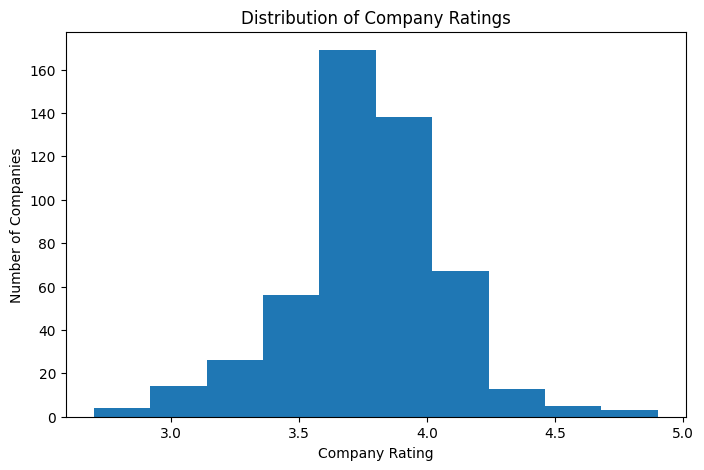

In [27]:
# Company Rating Distribution

plt.figure(figsize=(8, 5))

plt.hist(final_df["Company Rating"].dropna(), bins=10)

plt.title("Distribution of Company Ratings")
plt.xlabel("Company Rating")
plt.ylabel("Number of Companies")

plt.show()

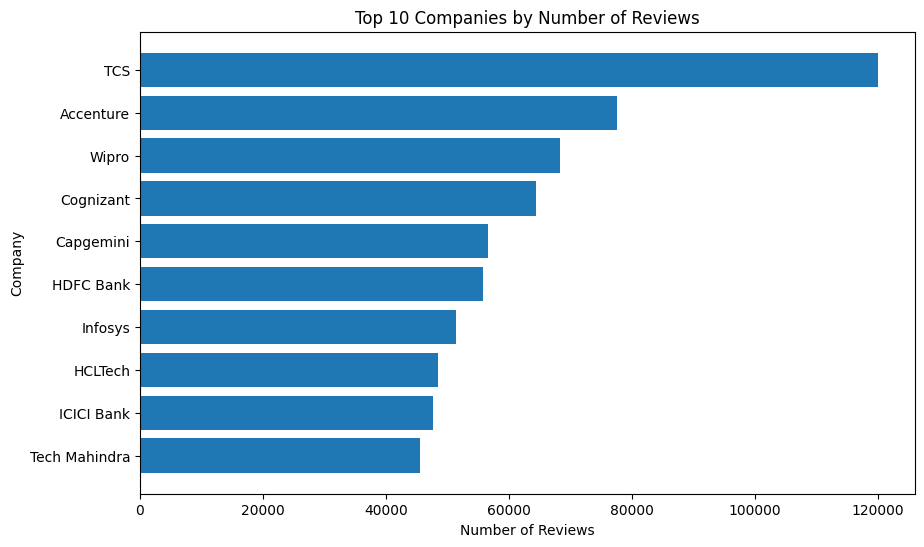

In [28]:
# Top 10 Companies by Reviews

top_reviewed = final_df.nlargest(10, "Reviews")

plt.figure(figsize=(10, 6))

plt.barh(top_reviewed["Company Name"], top_reviewed["Reviews"])

plt.title("Top 10 Companies by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Company")

plt.gca().invert_yaxis()

plt.show()

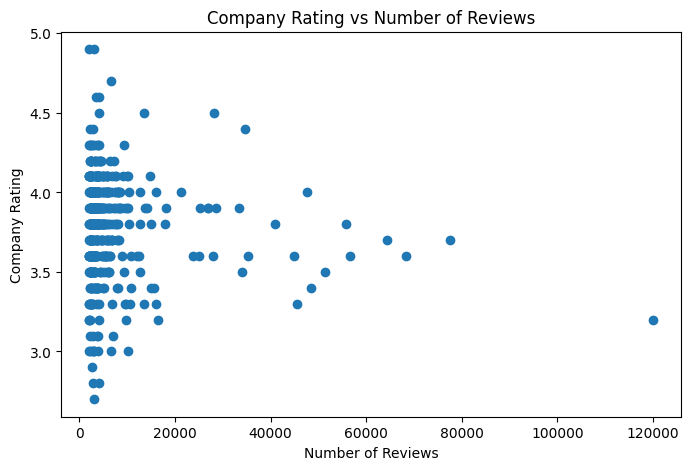

In [29]:
# Rating vs Reviews

plt.figure(figsize=(8, 5))

plt.scatter(
    final_df["Reviews"],
    final_df["Company Rating"]
)

plt.title("Company Rating vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Company Rating")

plt.show()

In [30]:
# Inspecting Raw Card Text for Extraction

for i in range(10):
    print(f"\n--- {raw_df.loc[i, 'Company Name']} ---")
    print(raw_df.loc[i, "Raw Card Text"])


--- TCS ---
TCS | Follow | 3.2 | (1.2L) | IT Services & Consulting | Bengaluru +481 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 1.2L | Reviews | 10.4L | Salaries | 11.4k | Interviews | 4.5k | Jobs | 11.1k | Benefits | 100 | Photos

--- Accenture ---
Accenture | Follow | 3.7 | (77.6k) | IT Services & Consulting | Bengaluru +283 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 77.6k | Reviews | 7.3L | Salaries | 9.6k | Interviews | 14.5k | Jobs | 7k | Benefits | 49 | Photos

--- Wipro ---
Wipro | Follow | 3.6 | (68.3k) | IT Services & Consulting | Hyderabad +394 other locations | Critically Rated For | Promotions, Salary, Work Satisfaction | To view salary insights | Select designation | 68.3k | Reviews | 4.9L | Salaries | 7k | Interviews | 7 | Jobs | 5k | Benefits | 123 | Photos

--- Cognizant ---
Cognizant | Follow | 3.7 | (

In [31]:
# Creating Visualization Folder

import os

os.makedirs("../04_Visualizations", exist_ok=True)

print("04_Visualizations folder is ready.")

04_Visualizations folder is ready.


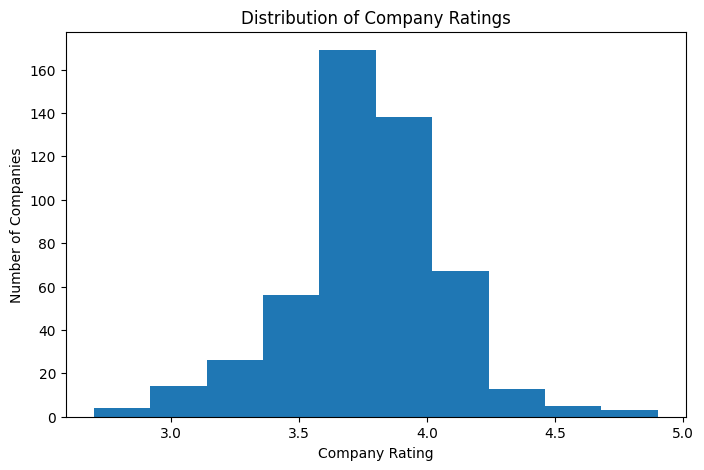

In [33]:
# Saving Rating Distribution Chart
plt.figure(figsize=(8, 5))
plt.hist(final_df["Company Rating"].dropna(), bins=10)

plt.title("Distribution of Company Ratings")
plt.xlabel("Company Rating")
plt.ylabel("Number of Companies")

plt.savefig("../04_Visualizations/company_rating_distribution.png")
plt.show()



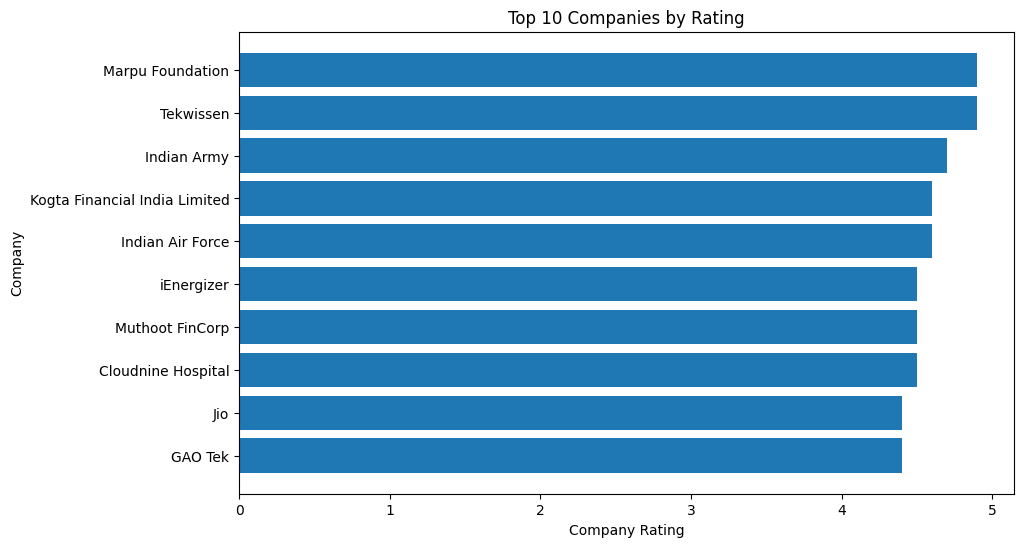

In [34]:

# Saving Top Rated Companies Chart

top_rated = final_df.nlargest(10, "Company Rating")

plt.figure(figsize=(10, 6))
plt.barh(top_rated["Company Name"], top_rated["Company Rating"])
plt.title("Top 10 Companies by Rating")
plt.xlabel("Company Rating")
plt.ylabel("Company")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/top_10_rated_companies.png",
            bbox_inches="tight")

plt.show()

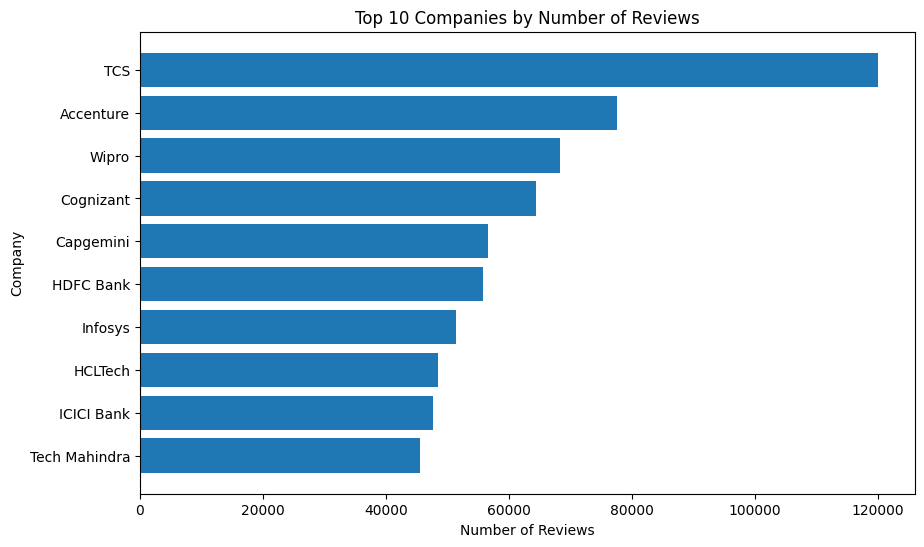

In [35]:
# Saving Top Reviewed Companies Chart

top_reviewed = final_df.nlargest(10, "Reviews")

plt.figure(figsize=(10, 6))
plt.barh(top_reviewed["Company Name"], top_reviewed["Reviews"])
plt.title("Top 10 Companies by Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Company")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/top_10_reviewed_companies.png",
            bbox_inches="tight")

plt.show()

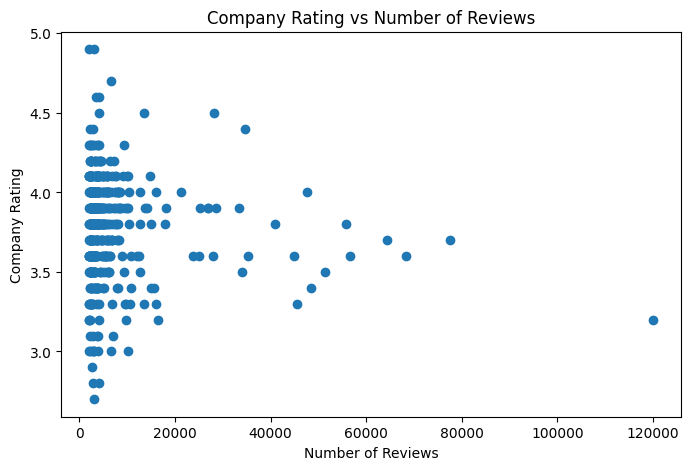

In [36]:
# Saving Rating vs Reviews Chart

plt.figure(figsize=(8, 5))
plt.scatter(final_df["Reviews"], final_df["Company Rating"])
plt.title("Company Rating vs Number of Reviews")
plt.xlabel("Number of Reviews")
plt.ylabel("Company Rating")

plt.savefig("../04_Visualizations/rating_vs_reviews.png",
            bbox_inches="tight")

plt.show()

## Industry and Location Analysis

Industry and location analysis helps us understand the business sectors and geographical distribution represented among the Top 500 companies.

The analysis identifies the most common industries and locations and compares average company ratings across industries.

These insights help understand where companies are concentrated and which industries have stronger employee ratings.

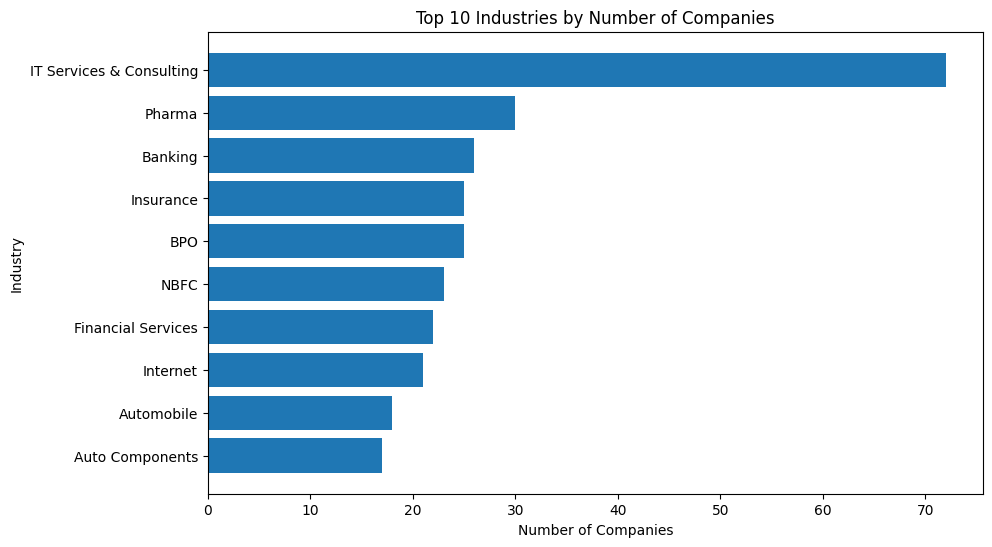

In [37]:
# Top 10 Industries

top_industries = final_df["Industry"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_industries.index, top_industries.values)

plt.title("Top 10 Industries by Number of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Industry")

plt.gca().invert_yaxis()
plt.show()

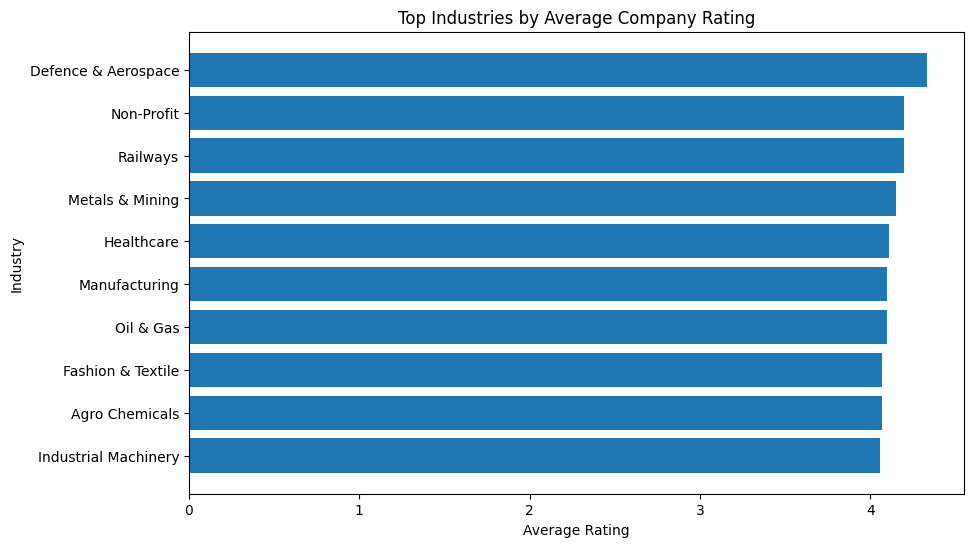

In [38]:
# Industry Rating Comparison

industry_plot = final_df.groupby("Industry")["Company Rating"].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(industry_plot.index, industry_plot.values)

plt.title("Top Industries by Average Company Rating")
plt.xlabel("Average Rating")
plt.ylabel("Industry")

plt.gca().invert_yaxis()
plt.show()

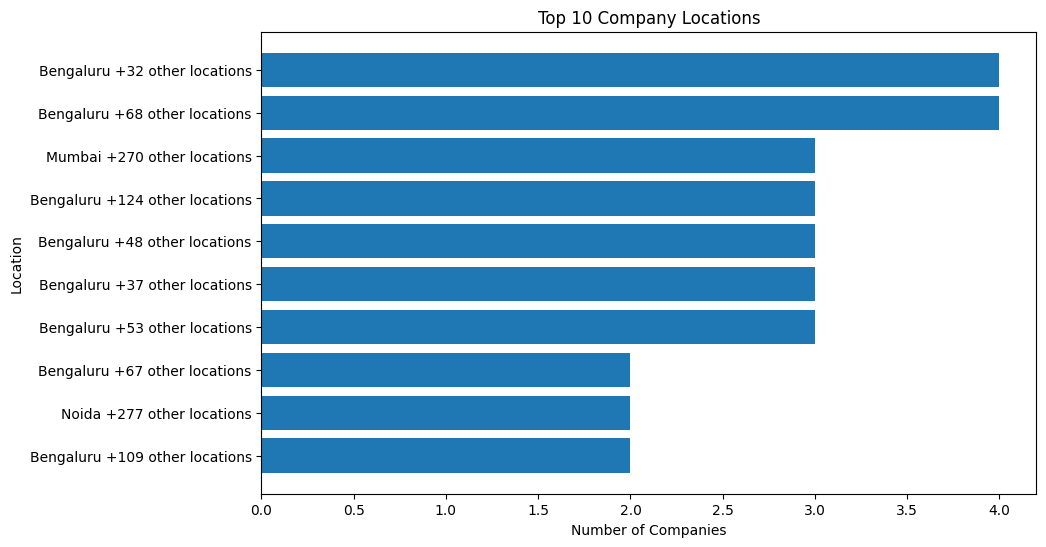

In [39]:
# Top 10 Company Locations

top_locations = final_df["Location"].value_counts().head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_locations.index, top_locations.values)

plt.title("Top 10 Company Locations")
plt.xlabel("Number of Companies")
plt.ylabel("Location")

plt.gca().invert_yaxis()
plt.show()

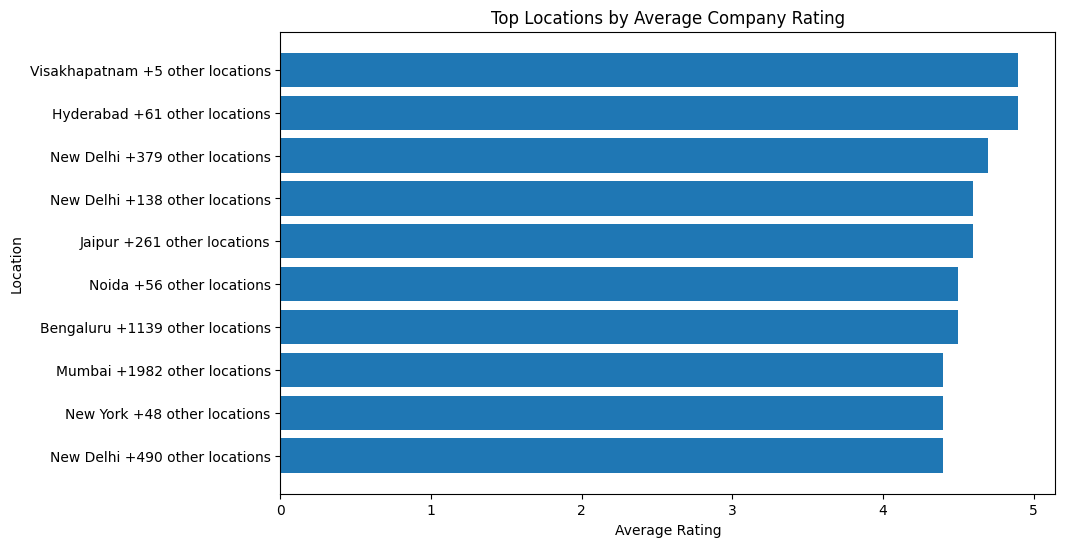

In [40]:
# Average Rating by Location

location_rating = final_df.groupby("Location")["Company Rating"].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10, 6))
plt.barh(location_rating.index, location_rating.values)

plt.title("Top Locations by Average Company Rating")
plt.xlabel("Average Rating")
plt.ylabel("Location")

plt.gca().invert_yaxis()
plt.show()

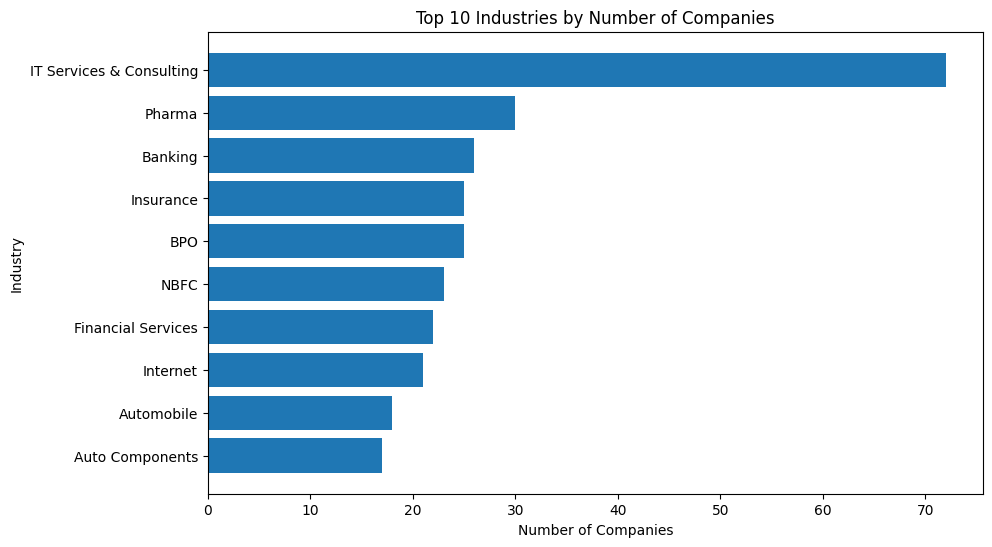

In [42]:
# Saving Top Industries Chart

plt.figure(figsize=(10, 6))
plt.barh(top_industries.index, top_industries.values)

plt.title("Top 10 Industries by Number of Companies")
plt.xlabel("Number of Companies")
plt.ylabel("Industry")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/top_10_industries.png",
            bbox_inches="tight")

plt.show()

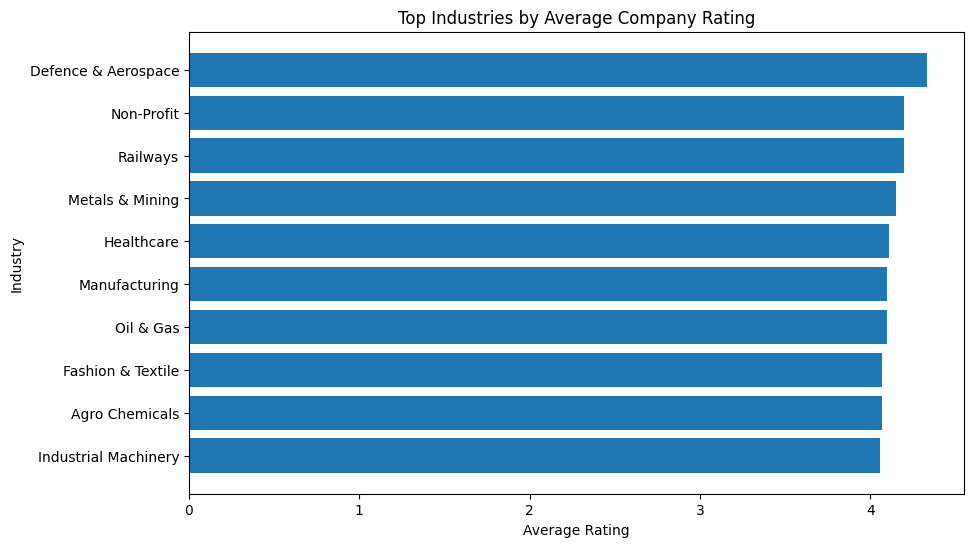

In [43]:
# Saving Industry Rating Chart

plt.figure(figsize=(10, 6))
plt.barh(industry_plot.index, industry_plot.values)

plt.title("Top Industries by Average Company Rating")
plt.xlabel("Average Rating")
plt.ylabel("Industry")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/industry_average_rating.png",
            bbox_inches="tight")

plt.show()

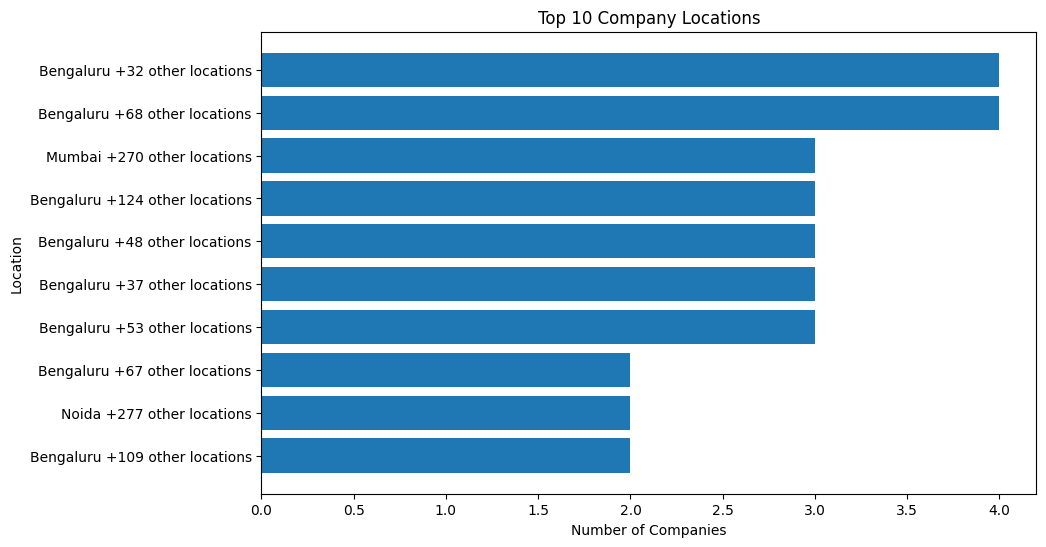

In [44]:
# Saving Company Locations Chart

plt.figure(figsize=(10, 6))
plt.barh(top_locations.index, top_locations.values)

plt.title("Top 10 Company Locations")
plt.xlabel("Number of Companies")
plt.ylabel("Location")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/top_10_company_locations.png",
            bbox_inches="tight")

plt.show()

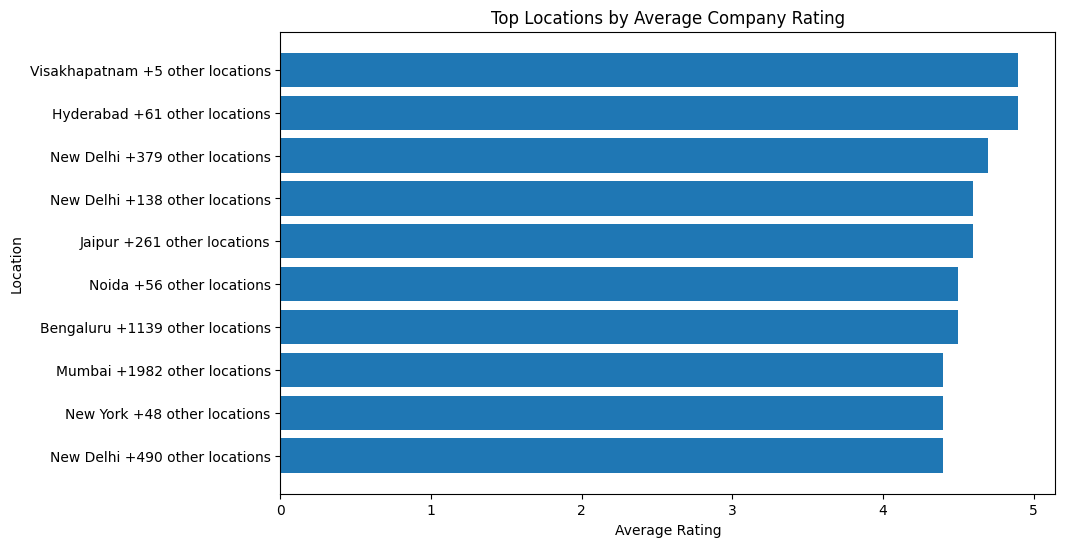

In [45]:
# Saving Location Rating Chart

plt.figure(figsize=(10, 6))
plt.barh(location_rating.index, location_rating.values)

plt.title("Top Locations by Average Company Rating")
plt.xlabel("Average Rating")
plt.ylabel("Location")
plt.gca().invert_yaxis()

plt.savefig("../04_Visualizations/location_average_rating.png",
            bbox_inches="tight")

plt.show()

## Data Dictionary

| Column | Description | Data Type |
|---|---|---|
| Company Name | Name of the company | Text |
| Raw Card Text | Original text extracted from the company card | Text |
| Company Rating | Employee rating of the company | Numeric |
| Reviews | Number of employee reviews | Numeric |
| Industry | Industry or business sector of the company | Text |
| Location | Company location information | Text |

The data dictionary describes the structure and meaning of each field in the final cleaned dataset. It helps users understand how the dataset can be interpreted and used for analysis.

## Data Cleaning Documentation
The raw scraped dataset was cleaned and prepared for analysis using the following steps:

- Duplicate company records were identified and removed using Company Name.
- Company Rating was converted to a numeric data type.
- Review counts were extracted using Regex and converted from values such as K, L, and M into numeric values.
- Records without valid Company Rating or Reviews were removed because these fields are required for the main analysis.
- Missing Industry and Location values were represented as `Not Available`.
- Text fields were standardized by removing unnecessary spaces and formatting inconsistencies.
- Company Size was excluded from the final analytical dataset because usable company-size information was not available in the scraped company cards.
- The final dataset was validated for duplicate records, missing values, and appropriate data types.
- The original raw dataset was preserved separately from the cleaned dataset.

These cleaning steps ensure that the final dataset is consistent, structured, and suitable for Exploratory Data Analysis and visualization.

## Business Insights

The analysis of the AmbitionBox Top 500 Companies dataset provides several useful business insights.

- Company ratings help identify organizations with stronger employee perceptions.
- Review volume indicates the level of employee engagement and the amount of available employee feedback.
- Industry analysis shows which business sectors are most represented among the Top 500 companies.
- Location analysis highlights the geographical concentration of companies.
- Comparing ratings with review counts helps understand whether highly reviewed companies also receive stronger employee ratings.
- Industry-level and location-level rating comparisons help identify areas with relatively higher employee satisfaction.

## Business Recommendations

Based on the analysis, the following recommendations can be considered:

- Companies should monitor employee ratings regularly to understand workplace perception.
- Organizations with lower ratings can investigate employee feedback and identify areas for improvement.
- High review volumes can provide valuable feedback for understanding employee expectations and workplace experience.
- Companies can benchmark their ratings against other organizations within the same industry.
- Location-level comparisons can help organizations identify regional differences in employee perceptions.
- Regular analysis of employee feedback can support better workplace policies and employee engagement strategies.

## Project Conclusion

This project demonstrates a complete data analytics workflow using web scraping and Regex techniques.

Company information was collected from AmbitionBox, transformed from raw web data into a structured dataset, cleaned using Python, and analyzed using Exploratory Data Analysis.

The analysis examined company ratings, review volumes, industries, and locations. Visualizations were created to identify important patterns and comparisons within the dataset.

The final results provide a structured view of the AmbitionBox Top 500 Companies and demonstrate how web-scraped data can be transformed into meaningful business insights for decision-making.